In [72]:
import pandas as pd
import numpy as np


In [73]:
df=pd.read_csv("techplacement.csv")

In [74]:
df.head()


,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,...,Moderate Hiring,46.7,ML Engineer,-25.7,30.3,4.9,4.4,8.7,8.6,Bull Market
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,...,Moderate Hiring,58.9,ML Engineer,-5.6,6.1,1.5,1.0,8.2,7.2,Bull Market
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,...,Hiring Freeze,85.4,Frontend Developer,7.0,-23.6,-14.9,5.6,4.5,5.9,Recession
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,...,Hiring Freeze,44.0,Frontend Developer,31.6,-22.3,-1.6,6.5,5.4,4.7,Recession
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,...,Moderate Hiring,53.2,Frontend Developer,85.3,26.6,9.8,9.3,6.7,5.8,Bull Market


In [75]:
df.shape

(12000, 23)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               12000 non-null  object 
 1   company_name            12000 non-null  object 
 2   industry                12000 non-null  object 
 3   country                 12000 non-null  object 
 4   company_size            12000 non-null  object 
 5   month                   12000 non-null  object 
 6   year                    12000 non-null  int64  
 7   layoffs_count           12000 non-null  int64  
 8   layoff_percentage       12000 non-null  float64
 9   reason_for_layoffs      12000 non-null  object 
 10  ai_automation_impact    12000 non-null  float64
 11  ai_replacement_risk     12000 non-null  float64
 12  open_roles              12000 non-null  int64  
 13  hiring_trend            12000 non-null  object 
 14  remote_jobs_percentage  12000 non-null

In [77]:
df['industry'].unique()

array(['AI', 'Cybersecurity', 'Gaming', 'FinTech', 'Cloud',
       'Social Media', 'E-Commerce'], dtype=object)

In [78]:
df['industry'].unique().size

7

<Axes: xlabel='industry', ylabel='layoffs_count'>

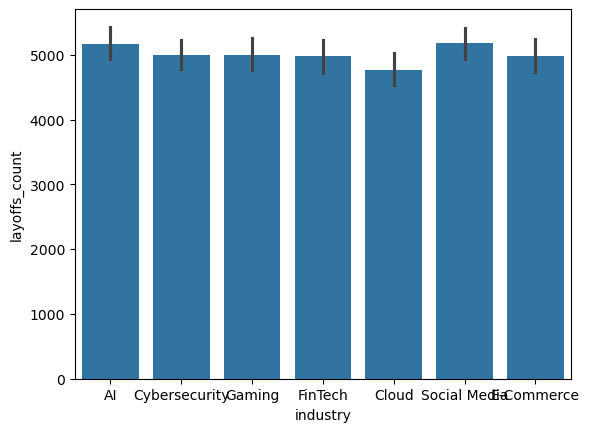

In [79]:
import seaborn as sns

sns.barplot(x=df['industry'], y=df['layoffs_count'], data=df)


<Axes: xlabel='country', ylabel='layoffs_count'>

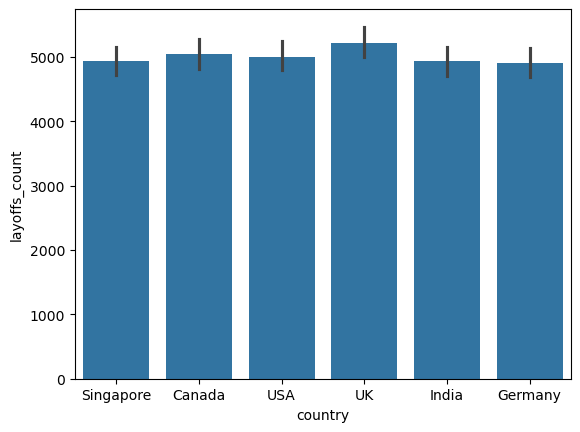

In [80]:
sns.barplot(x=df['country'], y=df['layoffs_count'], data=df)

In [81]:
import matplotlib.pyplot as plt


<Axes: xlabel='ai_adoption_level', ylabel='layoffs_count'>

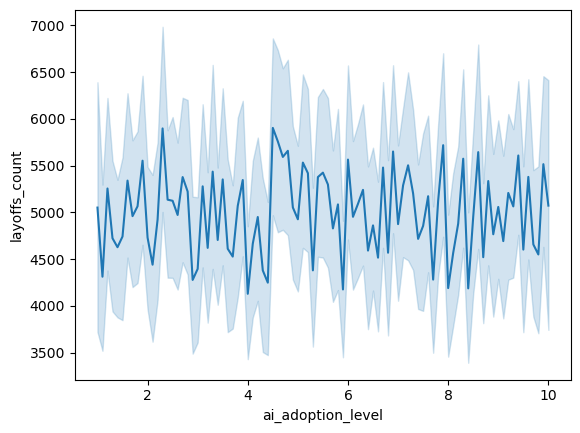

In [82]:
sns.lineplot(x=df['ai_adoption_level'], y=df['layoffs_count'], data=df)

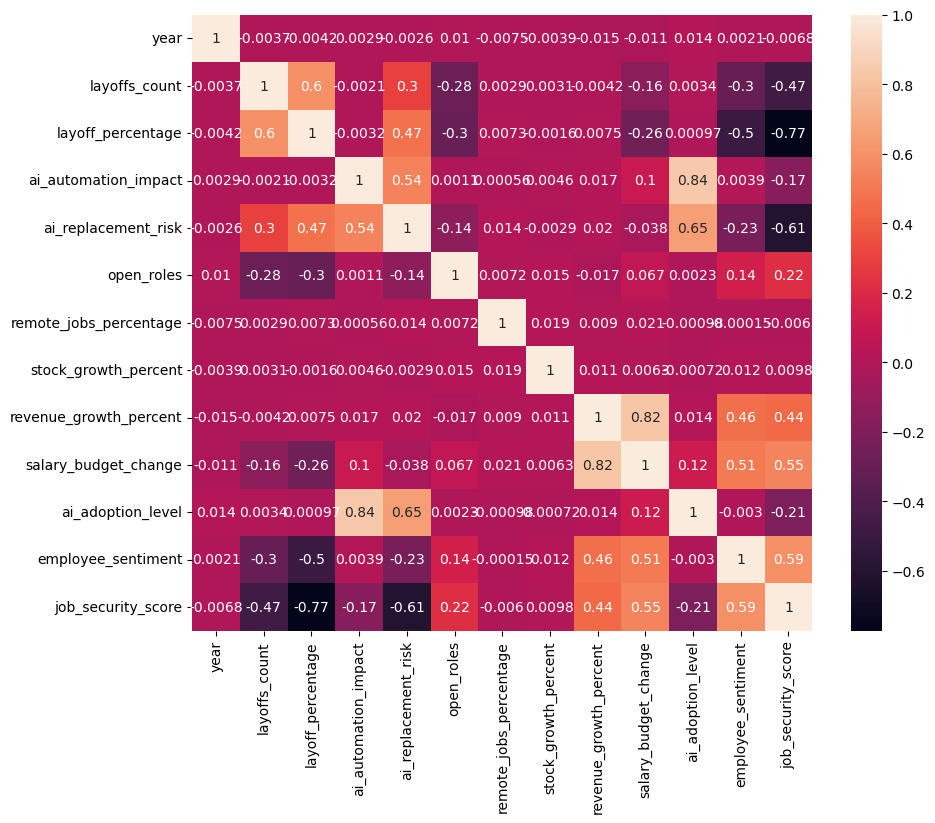

In [83]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()

In [84]:
df.isnull().sum()

record_id                 0
company_name              0
industry                  0
country                   0
company_size              0
month                     0
year                      0
layoffs_count             0
layoff_percentage         0
reason_for_layoffs        0
ai_automation_impact      0
ai_replacement_risk       0
open_roles                0
hiring_trend              0
remote_jobs_percentage    0
top_hiring_role           0
stock_growth_percent      0
revenue_growth_percent    0
salary_budget_change      0
ai_adoption_level         0
employee_sentiment        0
job_security_score        0
market_condition          0
dtype: int64

In [85]:
df.duplicated().sum()

0

In [86]:
df=df.drop(columns=['record_id','company_name'])

In [87]:
df['job_security_score'].describe()

count    12000.000000
mean         5.805033
std          1.649677
min          1.000000
25%          4.700000
50%          5.900000
75%          7.000000
max         10.000000
Name: job_security_score, dtype: float64

<Axes: xlabel='job_security_score', ylabel='Count'>

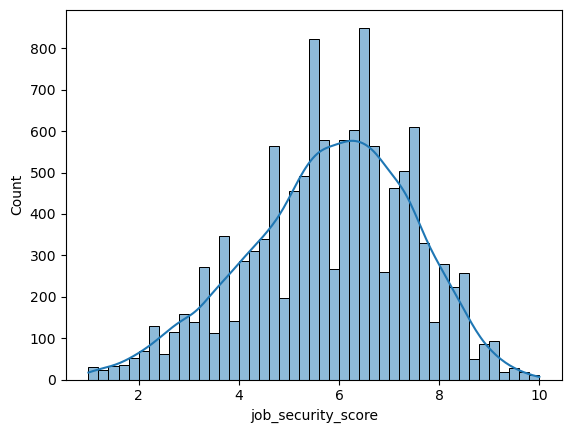

In [88]:
sns.histplot(df['job_security_score'], kde=True)

In [89]:
df.select_dtypes(include='object').columns

Index(['industry', 'country', 'company_size', 'month', 'reason_for_layoffs',
       'hiring_trend', 'top_hiring_role', 'market_condition'],
      dtype='object')

In [90]:
categorical_cols=list(df.select_dtypes(include='object').columns)
categorical_cols.remove('month')
categorical_cols

['industry',
 'country',
 'company_size',
 'reason_for_layoffs',
 'hiring_trend',
 'top_hiring_role',
 'market_condition']

In [91]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [92]:
cft=ColumnTransformer(transformers=[
    ('tnf1',OneHotEncoder(sparse_output=False,drop='first'),categorical_cols )
],remainder='passthrough')

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['job_security_score','month']), df['job_security_score'],
    test_size=0.2,
    random_state=42
)

In [94]:
X_train_transformed=cft.fit_transform(X_train)
X_train_transformed

array([[ 1. ,  0. ,  0. , ...,  1. ,  2.1,  6.8],
       [ 0. ,  1. ,  0. , ..., -3. ,  5.1,  5.9],
       [ 0. ,  1. ,  0. , ..., 10.4,  5.3,  7.8],
       ...,
       [ 0. ,  1. ,  0. , ..., -0.3,  4.9,  5.7],
       [ 0. ,  0. ,  1. , ...,  7.5,  8.3,  5. ],
       [ 0. ,  0. ,  0. , ..., -6.8,  7. ,  6.1]])

In [95]:
X_test_transformed=cft.transform(X_test)

In [96]:
from sklearn.metrics import accuracy_score

In [97]:
from sklearn.ensemble import RandomForestRegressor

In [98]:
rfg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rfg.fit(X_train_transformed, y_train)

y_pred_rf = rfg.predict(X_test_transformed)

In [99]:
from sklearn.metrics import r2_score, mean_squared_error

In [100]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

R2 Score: 0.8650267373720341
MSE: 0.36801253


In [101]:
from sklearn.linear_model import LinearRegression

In [102]:
lr = LinearRegression()
lr.fit(X_train_transformed, y_train)

LinearRegression()

In [103]:
y_pred_lr = lr.predict(X_test_transformed)

In [104]:
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

R2 Score: 0.8781230394582287
MSE: 0.33230469297697934


In [105]:
from xgboost import XGBRegressor

In [106]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_transformed, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [107]:
y_pred_xg= xgb.predict(X_test_transformed)

In [109]:
print("R2 Score:", r2_score(y_test, y_pred_xg))
print("MSE:", mean_squared_error(y_test, y_pred_xg))

R2 Score: 0.8671337369673155
MSE: 0.3622676718208969


In [110]:
from sklearn.model_selection import cross_val_score

In [111]:
scores = cross_val_score(
    lr,
    X_train_transformed,
    y_train,
    cv=5,
    scoring='r2'
)

print(scores)
print("Mean R2:", scores.mean())

[0.88053409 0.8696435  0.87596118 0.87522948 0.87425206]
Mean R2: 0.8751240636783155
